# Urinalysis Diagnosis Predictive Model
This notebook builds and evaluates classification models to predict urinalysis diagnosis (POSITIVE/NEGATIVE).

**Key considerations:**
- Dataset is heavily imbalanced (~17:1 NEGATIVE to POSITIVE)
- SMOTE is applied to balance training data
- Primary metric is **recall on POSITIVE class** (minimising missed diagnoses)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [2]:
urinalysis_data = pd.read_csv(r"datasets/urinalysis_data_cleaned.csv")

In [3]:
urinalysis_data.head()

,Age,Gender,Color,Transparency,Glucose,Protein,pH,Specific Gravity,WBC,RBC,Epithelial Cells,Mucous Threads,Amorphous Urates,Bacteria,Diagnosis
0,76.0,FEMALE,LIGHT YELLOW,CLEAR,NEGATIVE,NEGATIVE,5.0,1.010,1-3,0-2,OCCASIONAL,RARE,NONE SEEN,OCCASIONAL,NEGATIVE
1,9.0,MALE,DARK YELLOW,SLIGHTLY HAZY,NEGATIVE,1+,5.0,1.030,1-3,0-2,RARE,FEW,FEW,MODERATE,NEGATIVE
2,12.0,MALE,LIGHT YELLOW,SLIGHTLY HAZY,NEGATIVE,TRACE,5.0,1.030,0-3,0-2,RARE,FEW,MODERATE,RARE,NEGATIVE
3,77.0,MALE,BROWN,CLOUDY,NEGATIVE,1+,6.0,1.020,5-8,LOADED,RARE,RARE,NONE SEEN,FEW,NEGATIVE
4,29.0,FEMALE,YELLOW,HAZY,NEGATIVE,TRACE,6.0,1.025,1-4,0-2,RARE,RARE,NONE SEEN,FEW,NEGATIVE


In [4]:
urinalysis_data.isna().sum()

Age                 0
Gender              0
Color               0
Transparency        0
Glucose             0
Protein             0
pH                  0
Specific Gravity    0
WBC                 0
RBC                 0
Epithelial Cells    0
Mucous Threads      0
Amorphous Urates    0
Bacteria            0
Diagnosis           0
dtype: int64

## Feature Engineering

In [5]:
X = urinalysis_data.drop(columns=["Diagnosis"])
Y = urinalysis_data["Diagnosis"]

## Train-Test Split

In [6]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, stratify=Y, random_state=32)

## Feature Encoding

In [7]:
# Select categorical features
categorical_features = x_train.select_dtypes(include=["object"]).columns.tolist()

In [8]:
# Create instance
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

# Fit on training data only
encoder.fit(x_train[categorical_features])

# Transform both datasets
x_train[categorical_features] = encoder.transform(x_train[categorical_features])
x_test[categorical_features] = encoder.transform(x_test[categorical_features])

In [9]:
# FIX: Use .map() instead of .replace() to avoid FutureWarning
y_train = y_train.map({"NEGATIVE": 0, "POSITIVE": 1})
y_test = y_test.map({"NEGATIVE": 0, "POSITIVE": 1})

## Apply SMOTE
SMOTE balances the training set by generating synthetic minority (POSITIVE) samples.
It is applied **after** the train-test split to prevent data leakage.

In [10]:
smote = SMOTE(random_state=42)
x_retrained, y_retrained = smote.fit_resample(x_train, y_train)

print("Class distribution after SMOTE:")
print(pd.Series(y_retrained).value_counts())

Class distribution after SMOTE:
Diagnosis
0    1083
1    1083
Name: count, dtype: int64


## Feature Scaling

In [11]:
# Fit scaler on training data only, then transform both sets
scaler = StandardScaler()
x_retrained_scaled = scaler.fit_transform(x_retrained)
x_test_scaled = scaler.transform(x_test)

## Train Models
- Logistic Regression (baseline)
- Decision Tree Classifier
- Random Forest Classifier
- XGBoost Classifier

In [12]:
logistic_model = LogisticRegression(random_state=42)
decision_tree_model = DecisionTreeClassifier(random_state=42)
random_forest_model = RandomForestClassifier(random_state=42)
xgboost_model = XGBClassifier(random_state=42)

In [13]:
# FIX: Score on recall instead of accuracy — recall is the priority for medical diagnosis
# (minimising missed positives / false negatives)
logistic_scores = cross_val_score(logistic_model, x_retrained_scaled, y_retrained, cv=5, scoring='recall')
decision_tree_scores = cross_val_score(decision_tree_model, x_retrained_scaled, y_retrained, cv=5, scoring='recall')
random_forest_scores = cross_val_score(random_forest_model, x_retrained_scaled, y_retrained, cv=5, scoring='recall')
xgboost_scores = cross_val_score(xgboost_model, x_retrained_scaled, y_retrained, cv=5, scoring='recall')

print("Cross-Validation Recall (POSITIVE class):")
print(f"  Logistic Regression : {logistic_scores.mean():.4f}")
print(f"  Decision Tree       : {decision_tree_scores.mean():.4f}")
print(f"  Random Forest       : {random_forest_scores.mean():.4f}")
print(f"  XGBoost             : {xgboost_scores.mean():.4f}")

Cross-Validation Recall (POSITIVE class):
  Logistic Regression : 0.6685
  Decision Tree       : 0.9428
  Random Forest       : 0.9594
  XGBoost             : 0.9548


In [14]:
# Fit all models on SMOTE-resampled scaled data
logistic_model.fit(x_retrained_scaled, y_retrained)
decision_tree_model.fit(x_retrained_scaled, y_retrained)
random_forest_model.fit(x_retrained_scaled, y_retrained)
xgboost_model.fit(x_retrained_scaled, y_retrained)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Threshold Tuning
The default decision threshold is 0.5. For medical diagnosis, we lower it so the model
is more sensitive to positive cases — catching more true positives at the cost of some false alarms.

In [15]:
THRESHOLD = 0.2  # Tune this between 0.1–0.3 based on acceptable false alarm rate

def predict_with_threshold(model, X, threshold=THRESHOLD):
    proba = model.predict_proba(X)[:, 1]
    return (proba >= threshold).astype(int)

logistic_predictions = predict_with_threshold(logistic_model, x_test_scaled)
decision_tree_predictions = predict_with_threshold(decision_tree_model, x_test_scaled)
random_forest_predictions = predict_with_threshold(random_forest_model, x_test_scaled)
xgboost_predictions = predict_with_threshold(xgboost_model, x_test_scaled)

## Model Evaluation

In [16]:
# Accuracy scores (for reference — not the primary metric)
print("Accuracy Scores (threshold={}):" .format(THRESHOLD))
print(f"  Logistic Regression : {accuracy_score(y_test, logistic_predictions):.4f}")
print(f"  Decision Tree       : {accuracy_score(y_test, decision_tree_predictions):.4f}")
print(f"  Random Forest       : {accuracy_score(y_test, random_forest_predictions):.4f}")
print(f"  XGBoost             : {accuracy_score(y_test, xgboost_predictions):.4f}")

Accuracy Scores (threshold=0.2):
  Logistic Regression : 0.2544
  Decision Tree       : 0.9059
  Random Forest       : 0.9129
  XGBoost             : 0.9443


In [17]:
# Full classification reports — focus on POSITIVE class recall
models = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": decision_tree_predictions,
    "Random Forest": random_forest_predictions,
    "XGBoost": xgboost_predictions
}

for name, preds in models.items():
    print(f"{'='*60}")
    print(f" {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, preds, target_names=["NEGATIVE", "POSITIVE"]))

 Logistic Regression
              precision    recall  f1-score   support

    NEGATIVE       0.95      0.22      0.36       271
    POSITIVE       0.06      0.81      0.11        16

    accuracy                           0.25       287
   macro avg       0.51      0.52      0.23       287
weighted avg       0.90      0.25      0.35       287

 Decision Tree
              precision    recall  f1-score   support

    NEGATIVE       0.95      0.95      0.95       271
    POSITIVE       0.18      0.19      0.18        16

    accuracy                           0.91       287
   macro avg       0.56      0.57      0.57       287
weighted avg       0.91      0.91      0.91       287

 Random Forest
              precision    recall  f1-score   support

    NEGATIVE       0.97      0.94      0.95       271
    POSITIVE       0.30      0.44      0.36        16

    accuracy                           0.91       287
   macro avg       0.64      0.69      0.66       287
weighted avg       0.93

In [18]:
# FIX: AUC-ROC using predict_proba (probability scores), not hard predictions
print("AUC-ROC Scores (using predicted probabilities):")
for name, model in [("Logistic Regression", logistic_model),
                    ("Decision Tree", decision_tree_model),
                    ("Random Forest", random_forest_model),
                    ("XGBoost", xgboost_model)]:
    proba = model.predict_proba(x_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, proba)
    print(f"  {name:<22}: {auc:.4f}")

AUC-ROC Scores (using predicted probabilities):
  Logistic Regression   : 0.6882
  Decision Tree         : 0.5679
  Random Forest         : 0.7506
  XGBoost               : 0.7315


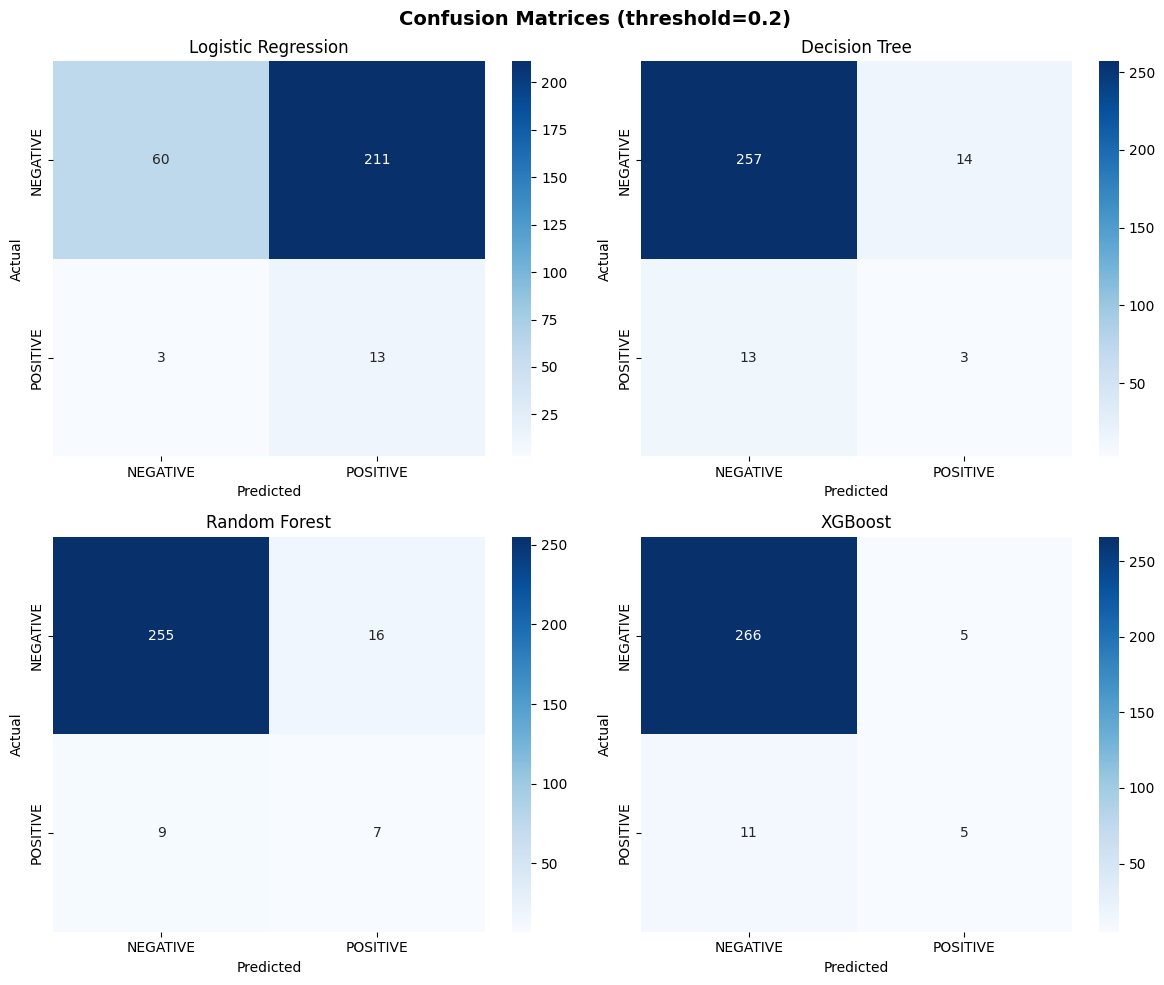

In [19]:
# Confusion Matrix Heatmaps
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle(f"Confusion Matrices (threshold={THRESHOLD})", fontsize=14, fontweight='bold')

for ax, (name, preds) in zip(axes.flat, models.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=["NEGATIVE", "POSITIVE"],
                yticklabels=["NEGATIVE", "POSITIVE"])
    ax.set_title(name)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

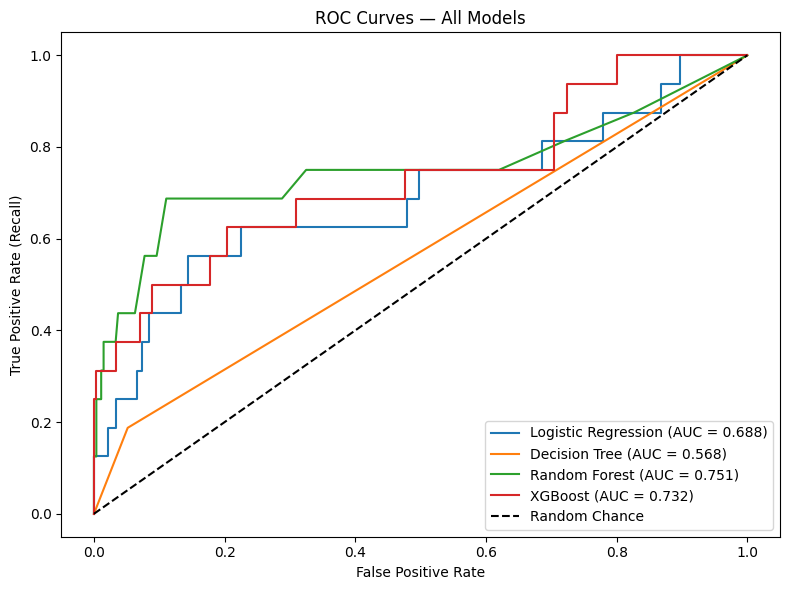

In [20]:
# ROC Curves for all models
plt.figure(figsize=(8, 6))

for name, model in [("Logistic Regression", logistic_model),
                    ("Decision Tree", decision_tree_model),
                    ("Random Forest", random_forest_model),
                    ("XGBoost", xgboost_model)]:
    proba = model.predict_proba(x_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curves — All Models")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Hyperparameter Tuning — XGBoost (GridSearchCV)

XGBoost is the best performing model. We now apply a comprehensive tuning strategy to maximise performance on the POSITIVE class.

### Parameters being tuned
| Parameter | Purpose |
|---|---|
| `scale_pos_weight` | Penalises missing positives — key for imbalanced data |
| `n_estimators` | Number of boosting rounds |
| `max_depth` | Tree depth — lower reduces overfitting |
| `learning_rate` | Step size per round — lower = more conservative |
| `subsample` | Row sampling per tree — reduces overfitting |
| `colsample_bytree` | Feature sampling per tree — reduces overfitting |
| `min_child_weight` | Minimum samples in a leaf — higher = more conservative |
| `gamma` | Minimum loss reduction to split — higher = more conservative |
| `reg_alpha` | L1 regularisation — drives sparse feature weights |
| `reg_lambda` | L2 regularisation — prevents large weights |

### Scoring strategy
We score on **F1, Recall, and F2** simultaneously. `refit='f2'` selects the best model by F2,
which weights recall twice as much as precision — appropriate for medical diagnosis.

In [21]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import fbeta_score, make_scorer

# Custom F2 scorer — weights recall 2x more than precision
f2_scorer = make_scorer(fbeta_score, beta=2)

# Calculate class imbalance ratio dynamically
neg_count = (y_retrained == 0).sum()
pos_count = (y_retrained == 1).sum()
imbalance_ratio = round(neg_count / pos_count)

print(f"Negative samples : {neg_count}")
print(f"Positive samples : {pos_count}")
print(f"Imbalance ratio  : {imbalance_ratio} (used as scale_pos_weight base)")

Negative samples : 1083
Positive samples : 1083
Imbalance ratio  : 1 (used as scale_pos_weight base)


In [22]:
param_grid = {
    # Boosting rounds + learning
    'n_estimators'     : [100, 200, 300, 500],
    'learning_rate'    : [0.01, 0.05, 0.1, 0.2],

    # Tree structure
    'max_depth'        : [3, 4, 5, 6],
    'min_child_weight' : [1, 3, 5, 7],
    'gamma'            : [0, 0.1, 0.3, 0.5],   # min loss reduction to make a split

    # Sampling — reduces overfitting
    'subsample'        : [0.6, 0.8, 1.0],
    'colsample_bytree' : [0.6, 0.8, 1.0],

    # Regularisation
    'reg_alpha'        : [0, 0.1, 0.5, 1.0],   # L1
    'reg_lambda'       : [1, 1.5, 2.0],         # L2

    # Imbalance compensation
    'scale_pos_weight' : [1, imbalance_ratio, imbalance_ratio + 5, imbalance_ratio + 10]
}

# Count total combinations
total = 1
for v in param_grid.values():
    total *= len(v)
print(f"Total grid combinations : {total:,}")
print(f"Total fits (x5 CV)      : {total * 5:,}")

Total grid combinations : 442,368
Total fits (x5 CV)      : 2,211,840


In [ ]:
grid_search = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    param_grid=param_grid,
    scoring={
        'f1'       : 'f1',
        'recall'   : 'recall',
        'precision': 'precision',
        'f2'       : f2_scorer
    },
    refit='f2',    # best model selected by F2 — favours recall over precision
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(x_retrained_scaled, y_retrained)

print("\nBest Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param:<22}: {value}")
print(f"\nBest CV F2 Score : {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 442368 candidates, totalling 2211840 fits


In [ ]:
# Inspect top 10 combinations across all metrics
results_df = pd.DataFrame(grid_search.cv_results_)

top10 = results_df[[
    'params',
    'mean_test_f2',
    'mean_test_f1',
    'mean_test_recall',
    'mean_test_precision'
]].sort_values('mean_test_f2', ascending=False).head(10)

top10.columns = ['Params', 'F2', 'F1', 'Recall', 'Precision']
top10 = top10.round(4).reset_index(drop=True)
top10.index += 1
print(top10[['F2', 'F1', 'Recall', 'Precision']].to_string())

## Threshold Sweep
After finding the best model, we sweep decision thresholds to find the value
that best balances recall and F1 for the POSITIVE class.

In [ ]:
tuned_xgb = grid_search.best_estimator_
tuned_proba = tuned_xgb.predict_proba(x_test_scaled)[:, 1]

thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print(f"{'Threshold':<12} {'Precision':<12} {'Recall':<10} {'F1':<10} {'F2':<10} {'Accuracy'}")
print("-" * 65)

best_f2 = 0
best_threshold = THRESHOLD

for t in thresholds:
    preds = (tuned_proba >= t).astype(int)
    prec  = precision_score(y_test, preds, zero_division=0)
    rec   = recall_score(y_test, preds, zero_division=0)
    f1    = f1_score(y_test, preds, zero_division=0)
    f2    = fbeta_score(y_test, preds, beta=2, zero_division=0)
    acc   = accuracy_score(y_test, preds)
    marker = ' ◄ best F2' if f2 > best_f2 else ''
    if f2 > best_f2:
        best_f2 = f2
        best_threshold = t
    print(f"{t:<12} {prec:<12.4f} {rec:<10.4f} {f1:<10.4f} {f2:<10.4f} {acc:.4f}{marker}")

print(f"\nOptimal threshold by F2: {best_threshold}")

## Final Evaluation — Default vs Tuned XGBoost
Using the optimal threshold identified above.

In [ ]:
# Apply optimal threshold to both models
default_proba = xgboost_model.predict_proba(x_test_scaled)[:, 1]

default_preds = (default_proba >= THRESHOLD).astype(int)
tuned_preds   = (tuned_proba >= best_threshold).astype(int)

# Side-by-side classification reports
print("DEFAULT XGBoost")
print("=" * 60)
print(classification_report(y_test, default_preds, target_names=["NEGATIVE", "POSITIVE"]))

print(f"TUNED XGBoost  (threshold={best_threshold})")
print("=" * 60)
print(classification_report(y_test, tuned_preds, target_names=["NEGATIVE", "POSITIVE"]))

In [ ]:
# Summary comparison table
metrics = {
    'Accuracy' : [accuracy_score(y_test, default_preds),             accuracy_score(y_test, tuned_preds)],
    'Precision': [precision_score(y_test, default_preds),            precision_score(y_test, tuned_preds)],
    'Recall'   : [recall_score(y_test, default_preds),               recall_score(y_test, tuned_preds)],
    'F1'       : [f1_score(y_test, default_preds),                   f1_score(y_test, tuned_preds)],
    'F2'       : [fbeta_score(y_test, default_preds, beta=2),        fbeta_score(y_test, tuned_preds, beta=2)],
    'AUC-ROC'  : [roc_auc_score(y_test, default_proba),              roc_auc_score(y_test, tuned_proba)]
}

comparison_df = pd.DataFrame(metrics, index=['Default XGBoost', 'Tuned XGBoost'])
print(comparison_df.round(4).to_string())

In [ ]:
# Confusion matrices — Default vs Tuned
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Default vs Tuned XGBoost — Confusion Matrices', fontsize=13, fontweight='bold')

for ax, (title, preds) in zip(axes, [
    (f"Default XGBoost (t={THRESHOLD})", default_preds),
    (f"Tuned XGBoost (t={best_threshold})", tuned_preds)
]):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues',
                xticklabels=["NEGATIVE", "POSITIVE"],
                yticklabels=["NEGATIVE", "POSITIVE"])
    ax.set_title(title)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.tight_layout()
plt.show()

In [ ]:
# ROC curve — Default vs Tuned
plt.figure(figsize=(8, 6))

for label, proba in [("Default XGBoost", default_proba), ("Tuned XGBoost", tuned_proba)]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label="Random Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve — Default vs Tuned XGBoost")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Feature Importance — Tuned XGBoost
Shows which features the tuned model relies on most heavily for its predictions.

In [ ]:
feature_names = X.columns.tolist()
importance_scores = tuned_xgb.feature_importances_

importance_df = pd.DataFrame({
    'Feature'   : feature_names,
    'Importance': importance_scores
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='Blues_r')
plt.title('Feature Importance — Tuned XGBoost', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

print("\nTop 10 Features:")
print(importance_df.head(10).to_string(index=False))